## 训练流程及思路
### 数据集
1. 下载数据集
2. 分析数据集的样式（尺寸、通道、训练集大小）
3. 数据归一化/标准化处理
4. 训练数据拆分（分成训练集和验证集）
### 定义数据对象
这里新增两个自定义对象
1. Dataset: 后续训练 存储/数据 就用这个对象，数据增强（例如加transform）、数据转换（例如tensor转换、cpu和gpu数据转换）都通过此对象实现
2. DataLoader: 数据加载类，入参为自定义的Dataset和batch_size\shuffle
### 定义神经网络结构
1. 最核心的内容：需要定义层数、池化、激活函数、全链接层、卷积核等参数的尺寸以及参数大小。这些都是根据经验或者输入图片大小和分类数量去配置
### 定义损失函数和优化器
损失函数就是用来判断每次识别的损失分数的，优化器就是根据分数怎么去修改每层的参数权重。
### 开始训练
定义epoch，循环开始训练
### 优化
根据每一次的结果去判断如何优化以提升准确率
### 使用模型
使用模型识别目标数据，然后生成提交文件

1. 加载数据集，然后观察数据样式

In [1]:
import pickle
import numpy as np
# 训练用数据
TRAIN_PATH = "datasets/train"
with open(TRAIN_PATH, "rb") as f:
    dictionary = pickle.load(f, encoding="bytes")
print(dictionary.keys())
raw_data = dictionary[b"data"]
images = raw_data.reshape(-1, 3, 32, 32)

# 测试数据，提交用
TRAIN_PATH = "datasets/test"
with open(TRAIN_PATH, "rb") as f:
    test_dictionary = pickle.load(f, encoding="bytes")
print(test_dictionary.keys())
test_raw_data = test_dictionary[b"data"]
test_images = test_raw_data.reshape(-1, 3, 32, 32)

# label值
labels = np.array(dictionary[b"fine_labels"])

print(images.shape) # (50000, 3, 32, 32)


# 在meta文件中找到对应的class编号和物理世界名称
META_PATH = "datasets/meta"

with open(META_PATH, "rb") as f:
    meta = pickle.load(f, encoding="bytes")

print(meta.keys())

fine_label_names = meta[b"fine_label_names"]

# bytes -> str
fine_label_names = [
    name.decode("utf-8")
    for name in fine_label_names
]


dict_keys([b'filenames', b'batch_label', b'fine_labels', b'coarse_labels', b'data'])
dict_keys([b'data', b'filenames'])
(50000, 3, 32, 32)
dict_keys([b'fine_label_names', b'coarse_label_names'])


打印其中一个图片看看效果

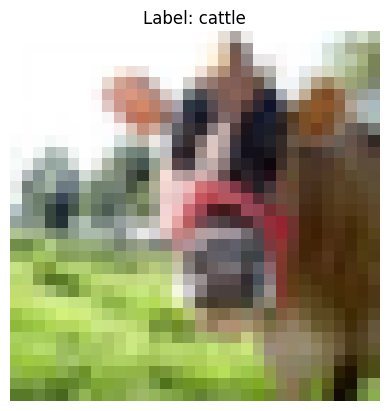

In [2]:
# 打印第一个图片看看图片和label
import matplotlib.pyplot as plt
plt.imshow(images[0].transpose(1, 2, 0))
plt.axis("off")
plt.title(f"Label: {fine_label_names[labels[0]]}")
plt.show()


2. 准备训练和验证数据集
a 数据归一化处理
b 分割数据集

In [3]:
#首先看看二者大小是否一致

print("特征数据形状:", images.shape)
print("目标类 形状:", labels.shape)
images = images.astype(np.float32) / 255.0
# 切分
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
print("训练集图片:", X_train.shape)
print("验证集图片:", X_val.shape)

print("训练集标签:", y_train.shape)
print("验证集标签:", y_val.shape)


特征数据形状: (50000, 3, 32, 32)
目标类 形状: (50000,)
训练集图片: (40000, 3, 32, 32)
验证集图片: (10000, 3, 32, 32)
训练集标签: (40000,)
验证集标签: (10000,)


3. 定义数据对象：Dataset、DataLoader
数据增强、batch_size等操作在此定义

In [4]:
from torch.utils.data import Dataset, DataLoader
import torch
class CIFARDataset(Dataset):
    def __init__(self, images, labels,transform):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform
    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        image = self.images[index]
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================
# 数据增强
# =========================
from torchvision import transforms
#训练集转换+增强
train_transform = transforms.Compose([
    transforms.ToPILImage(),

    # 1. 随机水平翻转
    transforms.RandomHorizontalFlip(),

    # 2. 随机裁剪
    transforms.RandomCrop(32, padding=4),

    # 3. 转成 Tensor
    transforms.ToTensor(),

    # 4. 随机擦除
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.20),
        ratio=(0.3, 3.3),
        value=0
    ),
    # 5. Normalize
    transforms.Normalize(
        mean=(0.5071, 0.4867, 0.4408),
        std=(0.2675, 0.2565, 0.2761)
    )
])

#验证集只转换，不增强
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
        transforms.Normalize(
    mean=(0.5071, 0.4867, 0.4408),
    std=(0.2675, 0.2565, 0.2761)
        )
])
#测试集维持同样变换，不然无法识别
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
        transforms.Normalize(
    mean=(0.5071, 0.4867, 0.4408),
    std=(0.2675, 0.2565, 0.2761)
        )
])


train_dataset = CIFARDataset(
    X_train,
    y_train,
    transform=train_transform
)

val_dataset = CIFARDataset(
    X_val,
    y_val,
    transform=val_transform
)
test_dataset = CIFARDataset(
    X_val,
    y_val,
    transform=test_transform
)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("数据集对象创建完成")

数据集对象创建完成


4. 定义神经网络结构

In [5]:
import torch.nn as nn
from torchvision import models
import torch.nn as nn
# 加载模型
model = models.resnet18(weights=None)
# =====================================
# CIFAR-100 专用修改
# =====================================

# 原版 ResNet18:
# 7×7, stride=2
#
# 你之前训练的是:
# 3×3, stride=1

model.conv1 = nn.Conv2d(
    3,
    64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)

model.maxpool = nn.Identity()

# CIFAR-100 图片只有 32×32
# 不使用 ImageNet ResNet 的 MaxPool

model.maxpool = nn.Identity()

# 100 个类别
model.fc = nn.Sequential(
    # nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 100)
)

print("模型创建完成")

模型创建完成


5. 初始化模型并创建迭代器和损失函数

In [6]:
import torch
# 有加速就用加速
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device(
#     "mps" if torch.backends.mps.is_available() else "cpu"
# )

#设置使用cuda
model = model.to(device)
print("使用 " ,device,"训练")
#使用交叉熵损失函数
criterion = nn.CrossEntropyLoss(
  # label_smoothing = 0.1
)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.00005,
    weight_decay=5e-4
)
# 学习率调度器： 可以让学习率自行变小。建议断点开，首次的时候直接用adam快速收敛
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=250,
    eta_min=1e-6
)

# optimizer = torch.optim.SGD(
#     model.parameters(),
#     lr=0.1,
#     momentum=0.9,
#     weight_decay=5e-4
# )
print("迭代器、损失函数、创建完成")

使用  cuda 训练
迭代器、损失函数、创建完成


6. 开始训练

In [ ]:
import os

checkpoint_path = "resnet18_checkpoint.pth"
best_model_path = "resnet18_best.pth"

num_epochs = 250
train_losses = []
train_accuracies = []
val_accuracies = []
start_epoch = 0
best_accuracy = 0
alpha=1.0

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )
    # 如果 checkpoint 有 scheduler，就加载
    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )
        print("已加载 scheduler 状态")
    else:
        print("checkpoint 中没有 scheduler_state_dict，不加载 scheduler")
        
    start_epoch = checkpoint["epoch"] + 1
    best_accuracy = checkpoint["best_accuracy"]

    print(f"从 Epoch {start_epoch} 继续训练")
    print(f"当前最佳验证准确率: {best_accuracy:.2f}%")

else:

    print("没有找到 checkpoint，从头开始训练")

# 开始训练
for epoch in range(start_epoch, num_epochs):

    # 设定模型为训练模式
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # print(model.conv1.weight.mean())
    for images, labels in train_loader:
        # 转换成GPU tensor
        images = images.to(device)
        labels = labels.to(device)
        
        # =========================
        # Mixup
        # =========================

        # 从 Beta(alpha, alpha) 分布中随机采样 lambda
        lam = np.random.beta(alpha, alpha)

        # 随机打乱当前 batch
        batch_size = images.size(0)
        index = torch.randperm(batch_size).to(device)

        images2 = images[index]
        labels2 = labels[index]

        # 混合图片
        mixed_images = lam * images + (1 - lam) * images2
        
        # 清除先前的前向传播
        optimizer.zero_grad()

        # 前向传播
        outputs = model(images)

        # 计算损失
        loss = criterion(outputs, labels)

        # 后向传播：计算梯度
        loss.backward()

        # 更新参数
        optimizer.step()

        # 累计这一轮batch的所有损失值
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        # 累加这个批次的数量
        total += labels.size(0)
        # 累加这个批次的计算正确的数量
        correct += (predicted == labels).sum().item()

    # print(model.conv1.weight.mean())
    # 第n遍全数据集跑一遍的训练损失
    train_loss = running_loss / len(train_loader)
    # 第n遍全数据集跑一遍的训练精确度
    train_accuracy = 100 * correct / total

     # =========================
    # 2. 验证模式
    # =========================
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            # 转换成 GPU Tensor
            images = images.to(
                device,
                non_blocking=True
            )
            labels = labels.to(
                device,
                non_blocking=True
            )

            # 前向传播
            outputs = model(images)

            # 获取预测类别
            _, predicted = torch.max(outputs, 1)

            # 累加数量
            total += labels.size(0)

            # 累加正确数量
            correct += (predicted == labels).sum().item()

    # 计算验证集准确率
    validation_accuracy = 100 * correct / total

    # 更新学习率调度器
    if epoch > 10:
        scheduler.step()

    # =========================
    # 3. 保存最佳模型
    # =========================
    if validation_accuracy > best_accuracy:

        best_accuracy = validation_accuracy

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_accuracy": best_accuracy
        }, best_model_path)

        print(">>> 保存新的最佳模型！")

    # 保存训练状态
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_accuracy": best_accuracy
    }, checkpoint_path)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(validation_accuracy)


    # =========================
    # 打印结果
    # =========================
    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"LR: {current_lr:.7f} "
        f"Train Loss: {train_loss:.4f} "
        f"Train Accuracy: {train_accuracy:.2f}% "
        f"Val Accuracy: {validation_accuracy:.2f}%"
    )

print(f"最佳验证集准确率为: {best_accuracy:.2f}%")

# 查看训练过程中的准确率变化
import matplotlib.pyplot as plt
plt.plot(train_accuracies, label="训练准确率")
plt.plot(val_accuracies, label="验证准确率")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

没有找到 checkpoint，从头开始训练
>>> 保存新的最佳模型！
Epoch [1/250] LR: 0.0000500 Train Loss: 3.9628 Train Accuracy: 9.96% Val Accuracy: 15.27%


7、使用训练好的模型去识别然后另存提交文档

In [ ]:
import pickle
import numpy as np
import torch
import os
import pandas as pd
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

batch_size = 256
# 测试数据，提交用
TRAIN_PATH = "datasets/test"
with open(TRAIN_PATH, "rb") as f:
    test_dictionary = pickle.load(f, encoding="bytes")
print(test_dictionary.keys())
test_raw_data = test_dictionary[b"data"]

test_images = test_raw_data.reshape(-1, 3, 32, 32)

print(test_images.shape) # (50000, 3, 32, 32)

test_images = test_images.transpose(0,2,3,1)
print(test_images.shape) # (50000, 3, 32, 32)

#测试集维持同样变换，不然无法识别
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
        transforms.Normalize(
    mean=(0.5071, 0.4867, 0.4408),
    std=(0.2675, 0.2565, 0.2761)
        )
])

class TestDataset(torch.utils.data.Dataset):

    def __init__(self, images, transform=None):

        self.images = images
        self.transform = transform


    def __len__(self):

        return len(self.images)


    def __getitem__(self,index):

        img = self.images[index]

        if self.transform:
            img = self.transform(img)

        return img

test_dataset = TestDataset(
    test_images,
    test_transform
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


device = "cuda"
model = models.resnet18(weights=None)
model.conv1 = nn.Conv2d(
    3,
    64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)
model.maxpool = nn.Identity()
# 100 个类别
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 100)
)
print("模型创建完成")
model = model.to(device)

model_path = "resnet18_best.pth"


if os.path.exists(model_path):
    checkpoint = torch.load(
        model_path,
        map_location=device
        )


model.load_state_dict(
    checkpoint["model_state_dict"]
)

# 评估模式
model.eval()

predictions = []

with torch.no_grad():

    for images in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        predictions.extend(
            preds.cpu().numpy()
        )


predictions = np.array(predictions)

# 输出到文件中
submission = pd.DataFrame({
    "id": np.arange(len(predictions)),
    "label": predictions
})

submission.head()
submission.to_csv("submission.csv", index=False)

print("submission.csv 创建成功")

二、分析原因-混淆矩阵

1. 将验证数据集全部用模型预测

In [ ]:
# 加载最佳模型 并设定评估模式
model = CNN().to(device)
model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)
model.eval()

import numpy as np

# 定义变量  预测值和真实标签值
all_predictions = []
all_labels = []

# 接下来代码不需要计算梯度
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        # 预测值
        outputs = model(images)

        # 对每一张图片，在 100 个类别里面找最大值。
        # 返回两个值：最大值 类别编号
        _, predictions = torch.max(outputs, 1)
        # 当前 batch 的所有预测结果，一个个追加到总列表里面
        all_predictions.extend(
            predictions.cpu().numpy()
        )
        # 当前 batch 的所有预测结果，一个个追加到总列表里面
        all_labels.extend(
            labels.numpy()
        )
# python list转numpy
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("预测数量:", len(all_predictions))
print("真实标签数量:", len(all_labels))

# 验证准确集  numpy逐个比较是否一致
accuracy = np.mean(
    all_predictions == all_labels
)

print(f"验证集准确率: {accuracy * 100:.2f}%")

2. 生成混淆矩阵（找出模型最容易把哪些类别认错，以及“真实类别 A → 错误预测成 B”发生了多少次。）
根据混淆矩阵判断为什么模型准确率上不去

In [ ]:
from sklearn.metrics import confusion_matrix
# 真实是第 i 类的时候，模型预测成第 j 类有多少张。
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=np.arange(100)
)
# 一共100类，所以矩阵是100*100
print(cm.shape)

cm_error = cm.copy()

# 对角线设置为0.因为对角线都是预测正确的，所以正确预测全部清除数据，方便后续找错误预测
np.fill_diagonal(cm_error, 0)

#找出错误次数最多的位置 错误次数从多到少对应的位置。
indices = np.argsort(
    # 把整个矩阵拉成一维
    cm_error.ravel()
)[::-1]

print("最严重的错误：")
 #找错误前20的
for index in indices[:20]:
    #indices是被压缩的一维数据，根据一维数据序号去找到对应的矩阵的位置，也就知道了真实标签和预测标签
    true_class, predicted_class = np.unravel_index(
        index,
        cm.shape
    )

    count = cm[true_class, predicted_class]

    print(
        f"真实类别 {true_class:2d} "
        f"→ 预测类别 {predicted_class:2d} "
        f": {count} 张"
    )

此时类别还是0-99这种数字，不利于观察，我们从meta文件中去找到class名称，然后建立混淆矩阵。

In [ ]:
# 在meta文件中找到对应的class编号和物理世界名称
META_PATH = "datasets/meta"

with open(META_PATH, "rb") as f:
    meta = pickle.load(f, encoding="bytes")

print(meta.keys())

fine_label_names = meta[b"fine_label_names"]

# bytes -> str
fine_label_names = [
    name.decode("utf-8")
    for name in fine_label_names
]

for index in indices[:20]:

    true_class, predicted_class = np.unravel_index(
        index,
        cm.shape
    )

    count = cm[true_class, predicted_class]

    print(
        f"真实：{true_class:2d} {fine_label_names[true_class]:15s}"
        f" → 预测：{predicted_class:2d} {fine_label_names[predicted_class]:15s}"
        f" : {count} 张"
    )

**分析现状**

根据上面的图片我们可以看到。预测错误的都是非常相似的。
比如 公交车识别成有轨电车 、男人识别成女人、沙发识别成床、女孩识别为女人、男人识别成女人
根据之前64%的验证集准确率失败原因我们可以总结出来了。
模型并不是学不会，模型已经学会总结了一些高纬度信息，比如但是更细节类别之间的区分能力不足。
我们可以得到结论，当前CNN的特征提取能力不够。
由于图像是32*32的，本身像素很低，所以我们还需要看看实际的图片长什么样，如果人眼都分不清，我觉得也情有可原。

接下来我们找两个类别去看看模型是怎么识别错误的，最后都错误的识别成什么类别了

In [ ]:
#看女孩-女人错误 图片
true_class = 35
predicted_class = 98

wrong_indices = np.where(
    (all_labels == true_class) &
    (all_predictions == predicted_class)
)[0]

print("错误数量:", len(wrong_indices))
print("验证集索引:", wrong_indices)
import matplotlib.pyplot as plt
import numpy as np

true_class = 35
predicted_class = 98

wrong_indices = np.where(
    (all_labels == true_class) &
    (all_predictions == predicted_class)
)[0]

print("错误数量:", len(wrong_indices))
print("索引:", wrong_indices)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(wrong_indices[:12]):

    image = X_val[idx]

    # (3, 32, 32) → (32, 32, 3)
    image = np.transpose(image, (1, 2, 0))

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.axis("off")

    plt.title(
        f"True: {fine_label_names[true_class]}\n"
        f"Pred: {fine_label_names[predicted_class]}"
    )

plt.tight_layout()
plt.show()

In [ ]:
# 看公交识别为有轨电车的图片
true_class = 13
predicted_class = 81

wrong_indices = np.where(
    (all_labels == true_class) &
    (all_predictions == predicted_class)
)[0]

print("错误数量:", len(wrong_indices))

plt.figure(figsize=(12, 8))

for i, idx in enumerate(wrong_indices[:12]):

    image = X_val[idx]

    # CHW → HWC
    image = np.transpose(image, (1, 2, 0))

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.axis("off")

    plt.title(
        f"True: {fine_label_names[true_class]}\n"
        f"Pred: {fine_label_names[predicted_class]}"
    )

plt.tight_layout()
plt.show()

通过这两个展示，我们能看到模型能识别到人，但是女孩-女人 公交车-有轨电车 这种细粒度的分类并不是很优秀。
这里能看到其实公交车还是很明显的，但是为什么没有分辨出来？
我们让模型再识别一次，然后我们去看模型对他的训练信心即也就是置信度的数值。

In [ ]:
true_class = 13
predicted_class = 81

wrong_indices = np.where(
    (all_labels == true_class) &
    (all_predictions == predicted_class)
)[0]
# 找到识别错误的图片对应的位置
print(wrong_indices)

model.eval()

with torch.no_grad():

    for idx in wrong_indices:

        image, label = val_dataset[idx]

        image = image.unsqueeze(0).to(device)

        output = model(image)
        # 转换成识别率
        probabilities = torch.softmax(output, dim=1)
        # 找到前五置信度预测
        top5_prob, top5_class = torch.topk(
            probabilities,
            5,
            dim=1
        )

        print("\n-------------------------")

        print(
            f"真实: {fine_label_names[label]}"
        )

        for rank in range(5):

            cls = top5_class[0, rank].item()
            prob = top5_prob[0, rank].item()

            print(
                f"Top {rank+1}: "
                f"{fine_label_names[cls]:15s} "
                f"{prob:.4f}"
            )

从结果来看，模型非常自信的预测错误了。
至此得出结论：1、中层空间能理解（知道这是一个交通工具/人）2、高层特征理解有问题，识别不到这是细粒度哪个分类

我们现在看看两个类别的方向差是什么样的
看看bus和有轨电车互相识别的准确率如何

In [ ]:
#先看看在验证集中二者的分布如何
bus_total = cm[13].sum()
streetcar_total = cm[81].sum()

print("bus 总数:", bus_total)
print("streetcar 总数:", streetcar_total)

print(
    "bus → streetcar 错误率:",
    cm[13, 81] / bus_total
)

print(
    "streetcar → bus 错误率:",
    cm[81, 13] / streetcar_total
)

二者样本数量相同，识别错误的数量不同，说明是非对称混淆。模型更容易把公交车判断成有轨电车
cnn已经能力不够了，我们需要换一个模型了。（这个不需要我们学会，只需要大厂出了新模型，我们会去试验知道什么场景用什么模型就行）

In [ ]:
从pth中加载模型

In [ ]:
import torch

pth_path = "resnet18_best.pth"

state_dict = torch.load(
    pth_path,
    map_location="cpu"
)

print(type(state_dict))

print("\n==============================")
print("参数名称 + Shape")
print("==============================")

for name, param in state_dict.items():
    print(f"{name:50s} {tuple(param.shape)}")

print("\n参数数量：", len(state_dict))